In [44]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 3
TS = 0.07

In [45]:
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
SCALER = joblib.load("./scalers/scaler.pkl")    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [46]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,R2_Val_Theta,MSE_Val_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_Test_3_Theta,MSE_Test_3_Theta
0,model_arch8-4_r0.01_seed4506,"[8, 4]",0.7,0.3,0.01,4506,0.809705,0.043308,0.310695,0.157360,-4.355520,1.748211,0.387630,0.140281,0.853575,0.034722,0.649222,0.115061
1,model_arch8-4_r0.01_seed8740,"[8, 4]",0.7,0.3,0.01,8740,0.823759,0.040110,0.460486,0.123164,-3.797895,1.566184,0.556402,0.101619,0.858435,0.033569,0.602821,0.130281
2,model_arch8-4_r0.01_seed7756,"[8, 4]",0.7,0.3,0.01,7756,0.795408,0.046562,0.283739,0.163513,-4.308407,1.732831,0.299571,0.160454,0.848095,0.036021,0.652771,0.113897
3,model_arch8-4_r0.01_seed1093,"[8, 4]",0.7,0.3,0.01,1093,0.799930,0.045533,0.307446,0.158101,-4.226948,1.706241,0.482220,0.118613,0.850465,0.035459,0.642213,0.117360
4,model_arch8-4_r0.01_seed6636,"[8, 4]",0.7,0.3,0.01,6636,0.833750,0.037836,0.246096,0.172107,-2.693689,1.205736,0.674259,0.074621,0.837042,0.038642,0.677608,0.105750


In [47]:
def PickModels(df, target, tr1=0.0, tr2=0.0, v1=0.0, t3=0.0):

    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"

    # filtro mínimo
    filtered = df[
        (df[r2_tr1] > tr1) &
        (df[r2_tr2] > tr2) &
        (df[r2_t3] > t3) &
        (df[r2_val] > v1)
    ]

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # 🔹 melhor para cada métrica
    best_tr1 = filtered.sort_values(r2_tr1, ascending=False).iloc[0]
    best_tr2 = filtered.sort_values(r2_tr2, ascending=False).iloc[0]
    best_val = filtered.sort_values(r2_val, ascending=False).iloc[0]
    best_t3 = filtered.sort_values(r2_t3, ascending=False).iloc[0]

    selected = pd.DataFrame([best_tr1, best_tr2, best_val, best_t3]).drop_duplicates()

    cols = ["model", "Neurons", "reg",  r2_tr1, r2_tr2, r2_val, r2_t3]

    table = selected[cols].copy()

    # 🔹 calcular média das métricas
    mean_values = table[[r2_tr1, r2_tr2, r2_val, r2_t3]].mean()

    mean_row = pd.DataFrame([{
        "model": "MEAN",
        "Neurons": "-",
        "reg": "-",
        r2_tr1: mean_values[r2_tr1],
        r2_tr2: mean_values[r2_tr2],
        r2_val: mean_values[r2_val],
        r2_t3: mean_values[r2_t3]
    }])

    table_mean = pd.concat([table, mean_row], ignore_index=True)

    display(table_mean)

    return selected

In [48]:
def BuildModel(architecture, r):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))
    regularizer =  tf.keras.regularizers.l2(r)
        
    for i, units in enumerate(architecture):

        if i < len(architecture) - 1:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    return_sequences=True,
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
            ))
        else:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
                )
            )

    model.add(tf.keras.layers.Dense(OUTPUT_SIZE,
                                    activation='linear',
                                    kernel_regularizer=regularizer,
                                    bias_regularizer=regularizer))

    return model

In [49]:
# def LoadModelFromRow(row):

#     # arquitetura
#     arch = row["Neurons"]
#     if isinstance(arch, str):
#         arch = ast.literal_eval(arch)

#     r = float(row["reg"])
#     model_name = row["model"]

#     weights_path = f"weights/{model_name}.weights.h5"

#     # build
#     model = BuildModel(arch, r)
#     model.build((None, TIME_STEPS, INPUT_SIZE))

#     # load pesos
#     model.load_weights(weights_path)

#     return model

In [50]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [51]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [52]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [59]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.0, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=1, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    # 🔥 Agora: colunas dobradas (y + dy)
    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = NormDataset[TARGET_INT] # theta
        dy = Datasets[i][TARGET]    # dtheta

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [60]:
rows = PickModels(results, "Theta", tr1=-10, tr2=-10, v1=-10, t3=-10)

,model,Neurons,reg,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_Theta,R2_Test_3_Theta
0,model_arch8-4_r0.01_seed6636,"[8, 4]",0.01,0.833750,0.246096,-2.693689,0.677608
1,model_arch8-4_r0.01_seed8740,"[8, 4]",0.01,0.823759,0.460486,-3.797895,0.602821
2,MEAN,-,-,0.828754,0.353291,-3.245792,0.640215


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 3, 8)              104       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 4)                 52        
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 161 (644.00 Byte)
Trainable params: 161 (644.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Theta | Train_1 -> R² = 0.8338, MSE = 3.7836e-02
Theta | Train_2 -> R² = 0.2461, MSE = 1.7211e-01
Theta | Test_1 -> R² = 0.6743, MSE = 7.4621e-02
Theta | Test_2 -> R² = 0.8370, MSE = 3.8642e-02
Theta | Test_3 -> R² = 0.6776, MSE = 1.0575e-01
Theta | Val -> R² = -2.6937, MSE = 1.205

model                model_arch8-4_r0.01_seed6636
Neurons                                    [8, 4]
Ld                                            0.7
Lp                                            0.3
reg                                          0.01
seed                                         6636
R2_Train_1_Theta                          0.83375
MSE_Train_1_Theta                        0.037836
R2_Train_2_Theta                         0.246096
MSE_Train_2_Theta                        0.172107
R2_Val_Theta                            -2.693689
MSE_Val_Theta                            1.205736
R2_Test_1_Theta                          0.674259
MSE_Test_1_Theta                         0.074621
R2_Test_2_Theta                          0.837042
MSE_Test_2_Theta                         0.038642
R2_Test_3_Theta                          0.677608
MSE_Test_3_Theta                          0.10575
Name: 4, dtype: object

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 3, 8)              104       
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 4)                 52        
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 161 (644.00 Byte)
Trainable params: 161 (644.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Theta | Train_1 -> R² = 0.8238, MSE = 4.0110e-02
Theta | Train_2 -> R² = 0.4605, MSE = 1.2316e-01
Theta | Test_1 -> R² = 0.5564, MSE = 1.0162e-01
Theta | Test_2 -> R² = 0.8584, MSE = 3.3569e-02
Theta | Test_3 -> R² = 0.6028, MSE = 1.3028e-01
Theta | Val -> R² = -3.7979, MSE = 1.566

model                model_arch8-4_r0.01_seed8740
Neurons                                    [8, 4]
Ld                                            0.7
Lp                                            0.3
reg                                          0.01
seed                                         8740
R2_Train_1_Theta                         0.823759
MSE_Train_1_Theta                         0.04011
R2_Train_2_Theta                         0.460486
MSE_Train_2_Theta                        0.123164
R2_Val_Theta                            -3.797895
MSE_Val_Theta                            1.566184
R2_Test_1_Theta                          0.556402
MSE_Test_1_Theta                         0.101619
R2_Test_2_Theta                          0.858435
MSE_Test_2_Theta                         0.033569
R2_Test_3_Theta                          0.602821
MSE_Test_3_Theta                         0.130281
Name: 1, dtype: object

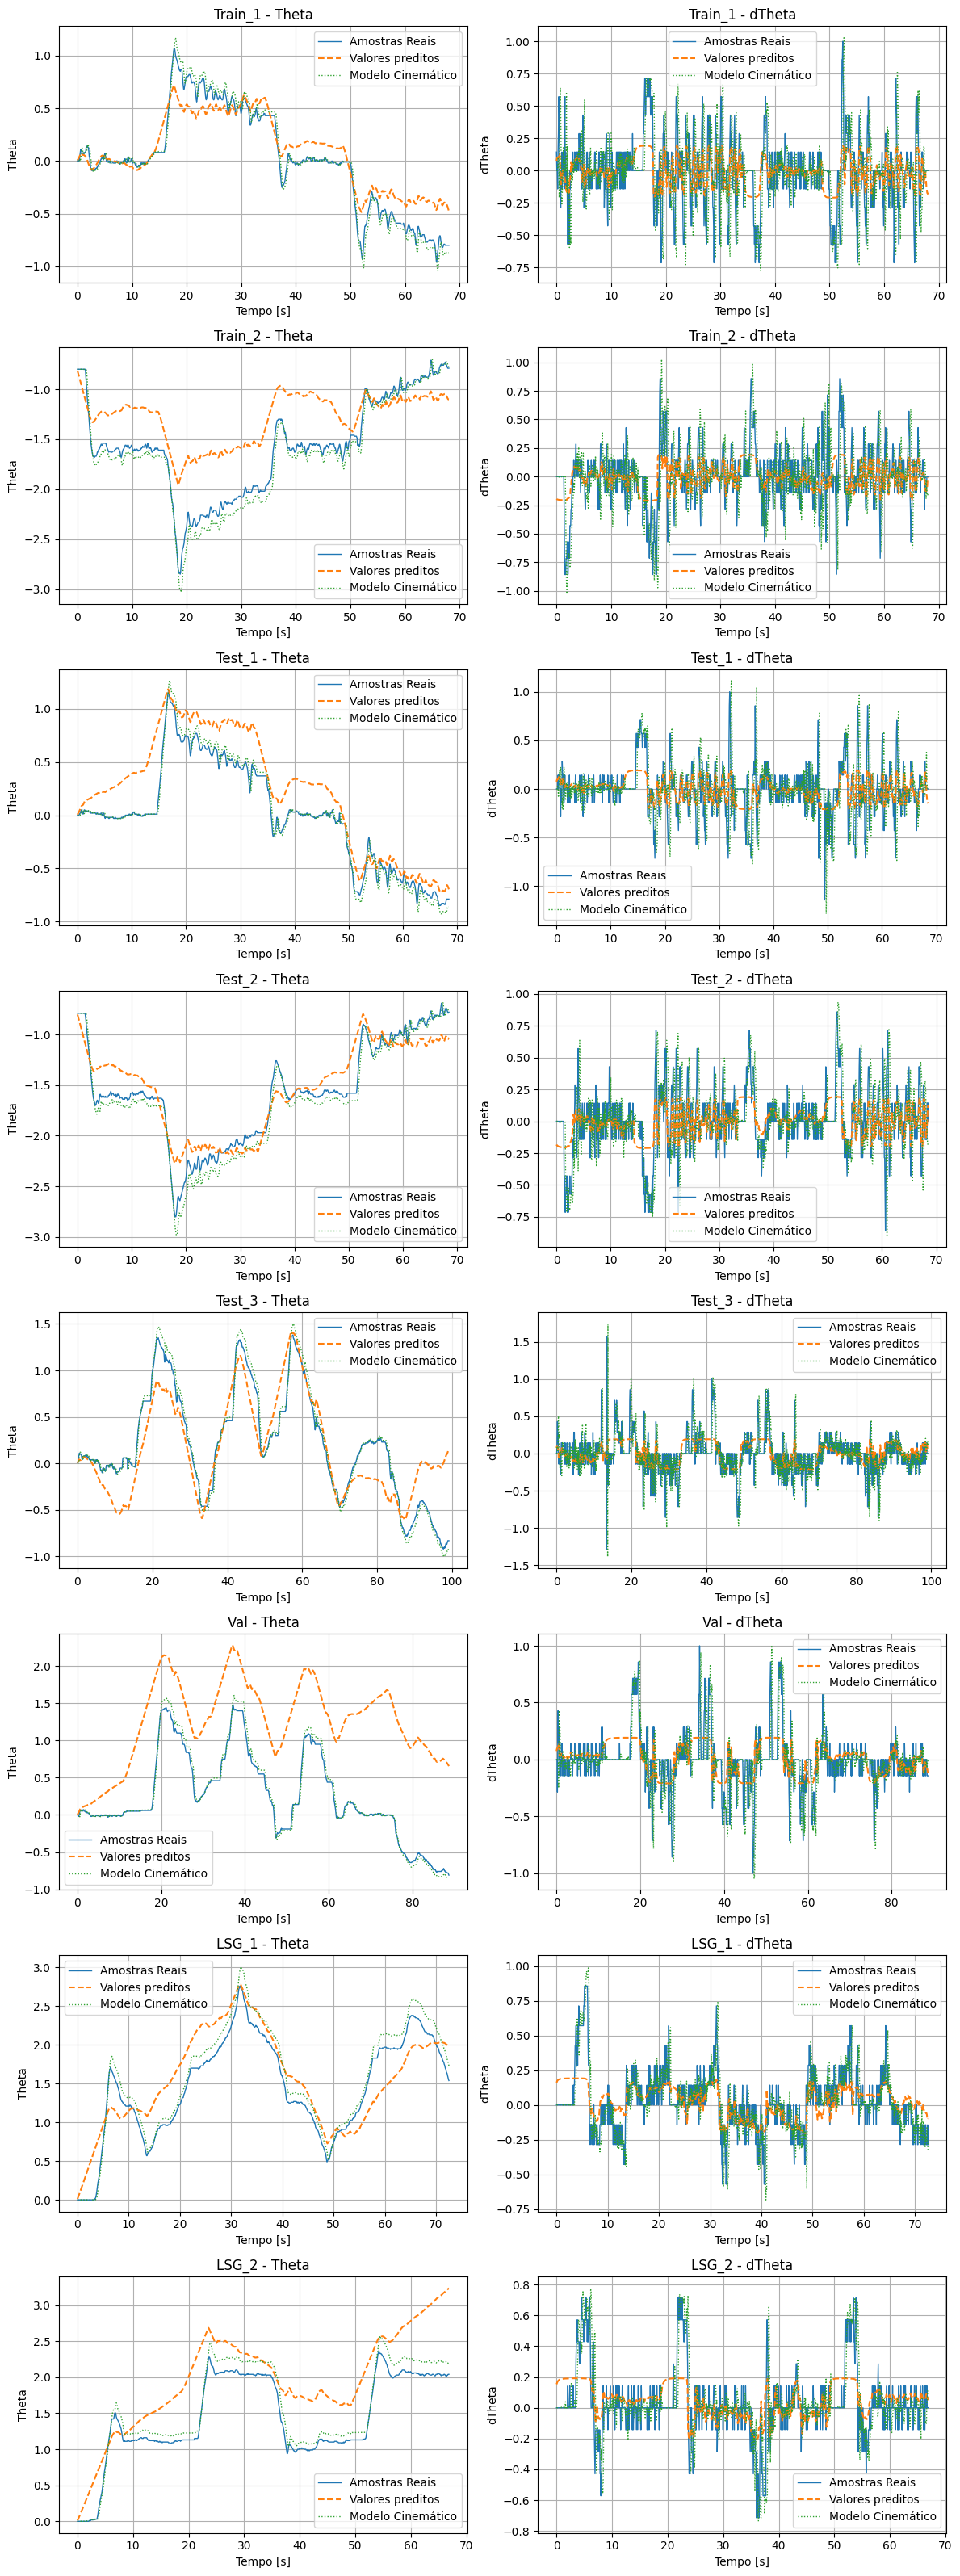

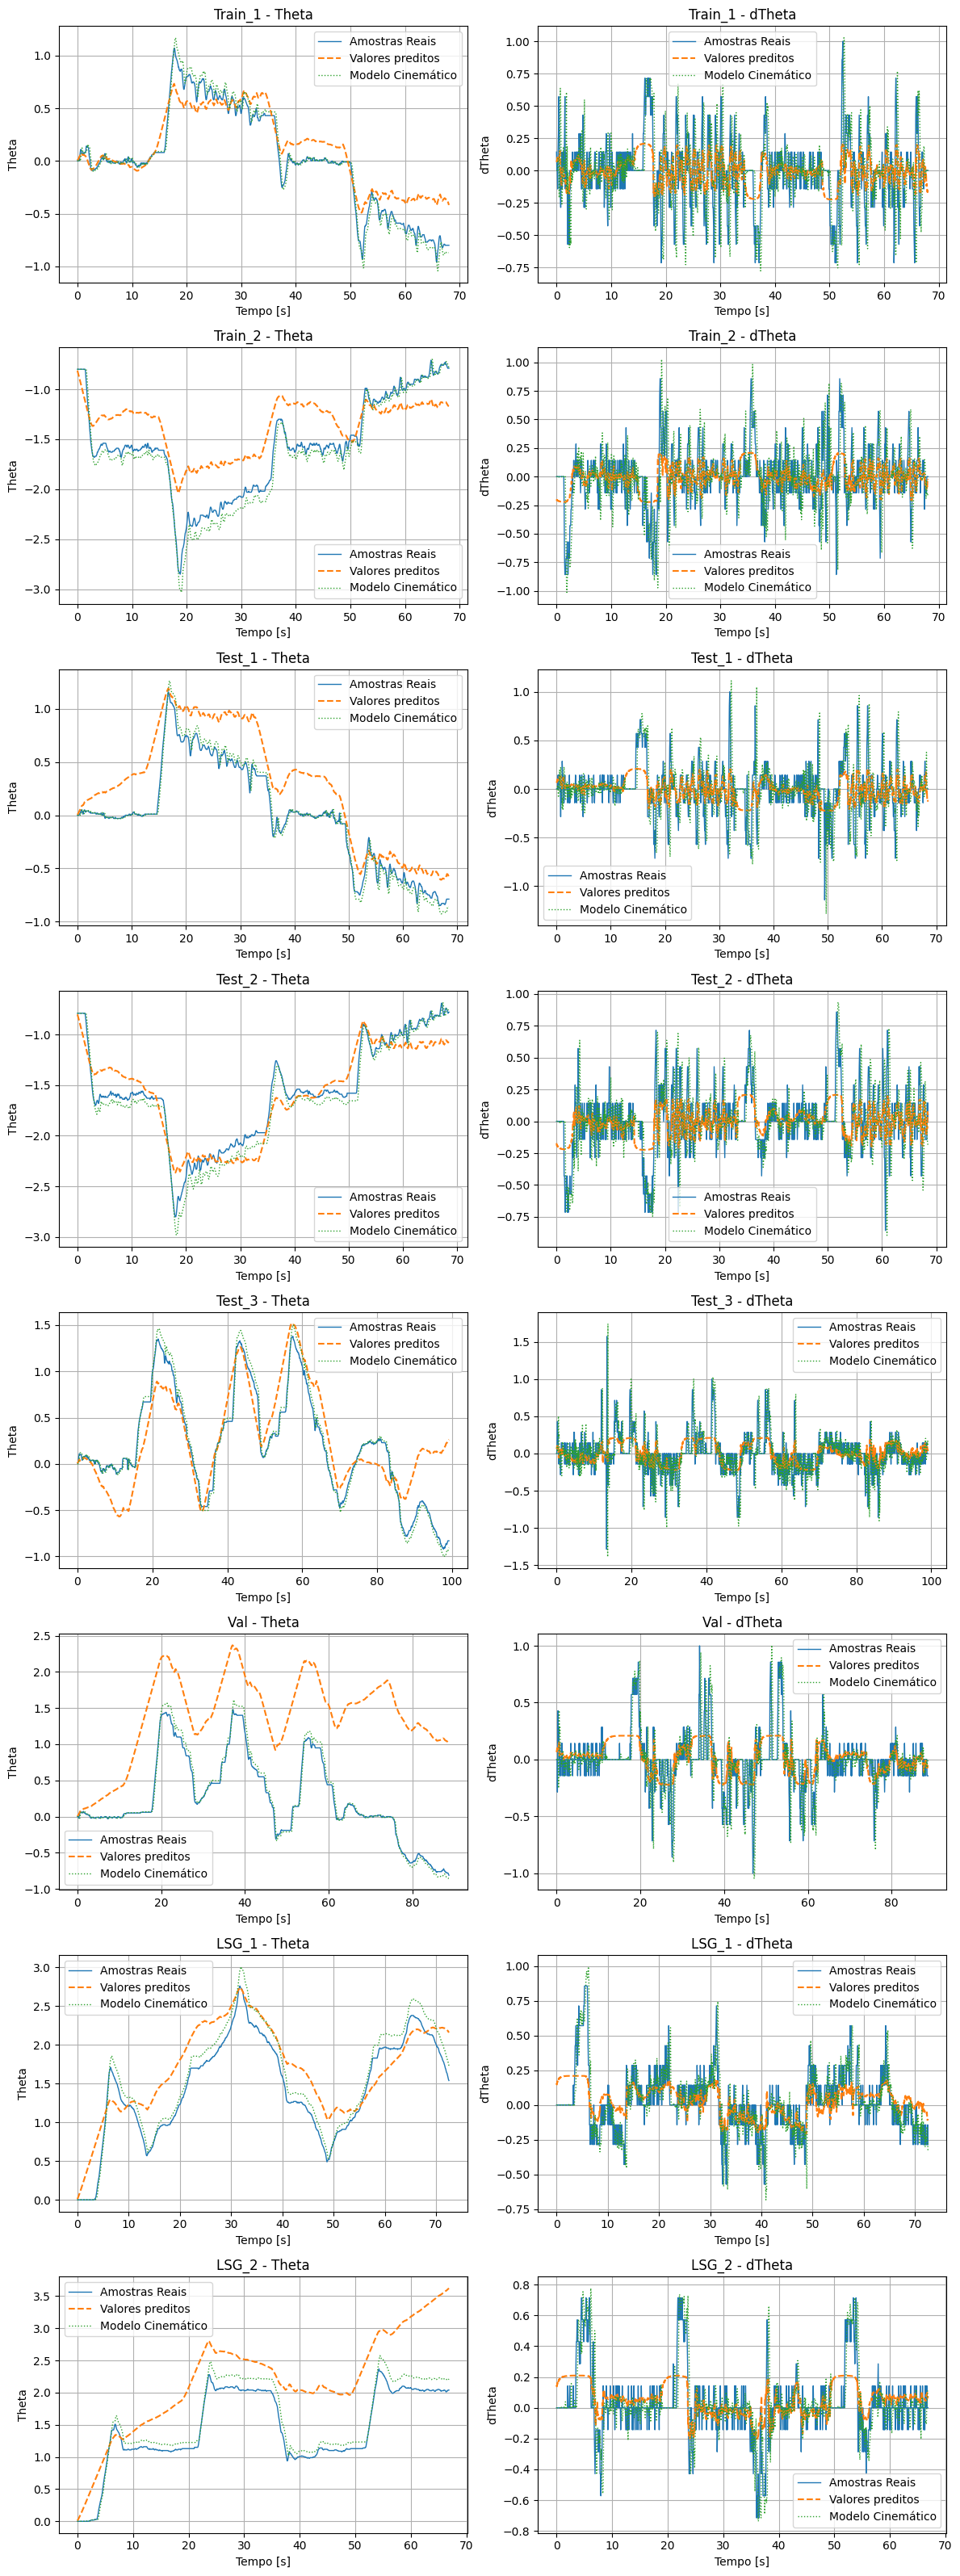

In [61]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model = LoadModelFromRow(row)
    model.summary()
    metrics = EvalModel(model)
    display(row)